# 05 · Analysis 3: the national improvement was not shared evenly

Analyses 1 and 2 used Canada-level rows. But Canada is only **1 of the 14 geographies** in this
extract, the other 13 provinces and territories account for roughly 93% of the rows, and unlike
Q2 2024's national cells they contain **no missing values at all**.

**Question:** the national sales outlook rose 2.9 pp into Q2 2024. Did businesses across the country
actually experience that?

**Measure:** the change in the share expecting sales to increase, Q1 2024 → Q2 2024, for every
geography, reported alongside each jurisdiction's four-quarter volatility, because the two have to
be read together.

## Setup

In [ ]:
import sys
from pathlib import Path

# Walk up until src/csbc.py is found, so the notebook runs whether Jupyter was started
# in the project root or in src/. Nothing here depends on an absolute path.
_here = Path.cwd().resolve()
_root = next(p for p in (_here, *_here.parents) if (p / "src" / "csbc.py").exists())
sys.path.insert(0, str(_root / "src"))

import pandas as pd
import matplotlib.pyplot as plt

import csbc

csbc.ensure_dirs()
csbc.apply_chart_theme()

pd.set_option("display.width", 120)
pd.set_option("display.max_colwidth", 48)

print(f"project: {csbc.ROOT.name}/")
print(f"raw data: {len(sorted(csbc.RAW_DIR.glob('*.csv')))} quarterly CSVs in data/raw")

project: business_data_lab_assignment/
raw data: 4 quarterly CSVs in data/raw


In [ ]:
csbc_data = csbc.load_combined()
QUARTERS = csbc.sort_quarters(csbc_data["Quarter"])

print(f"{len(csbc_data):,} rows | quarters: {', '.join(QUARTERS)}")

9,408 rows | quarters: Q3 2023, Q4 2023, Q1 2024, Q2 2024


In [ ]:
# Non-Canada rows are fully populated, so this analysis needs no missing-value handling.
provinces = csbc_data[csbc_data["GEO"] != "Canada"]
print(f"non-Canada rows: {len(provinces):,} of {len(csbc_data):,} "
      f"({len(provinces) / len(csbc_data) * 100:.0f}%)")
print(f"missing VALUE cells among them: {provinces['VALUE'].isna().sum()}")

non-Canada rows: 8,736 of 9,408 (93%)
missing VALUE cells among them: 0


## Change by geography

In [ ]:
regional = csbc.regional_table(csbc_data, "Q1 2024", "Q2 2024", metric="Sales")
regional

,Q1 2024,Q2 2024,change_pp,volatility_sd
GEO,,,,
Yukon,7.3,21.5,14.2,6.2
Prince Edward Island,16.6,28.8,12.2,6.9
Northwest Territories,10.1,17.2,7.1,3.1
Alberta,17.6,23.6,6.0,3.6
Nova Scotia,21.1,26.4,5.3,4.1
Nunavut,9.2,14.4,5.2,4.6
British Columbia,17.4,22.2,4.8,3.1
New Brunswick,17.4,21.9,4.5,2.2
Newfoundland and Labrador,15.9,19.7,3.8,2.8


In [ ]:
national_change = regional.loc["Canada", "change_pp"]
others = regional.drop(index="Canada")

print(f"national change                      {national_change:+.1f} pp")
print(f"jurisdictions improving              {(others['change_pp'] > 0).sum()} of {len(others)}")
print(f"jurisdictions declining              {(others['change_pp'] < 0).sum()}")
print(f"beating the national change          {(others['change_pp'] > national_change).sum()}")
print(f"spread across jurisdictions          {others['change_pp'].min():+.1f} to "
      f"{others['change_pp'].max():+.1f} pp")

national change                      +2.9 pp
jurisdictions improving              12 of 13
jurisdictions declining              1
beating the national change          9
spread across jurisdictions          -1.3 to +14.2 pp


## Chart

**Form: dumbbell.** Two points per row joined by a line, because the quantity of interest is the
*gap* between two quarters. A grouped bar chart would show the same numbers but force the reader to
subtract; here the connector length *is* the change, and its colour is the direction.

Hollow dot = Q1 2024, filled = Q2 2024, so the time order survives even without colour. Canada is
banded as a reference rather than presented as a peer of the provinces.

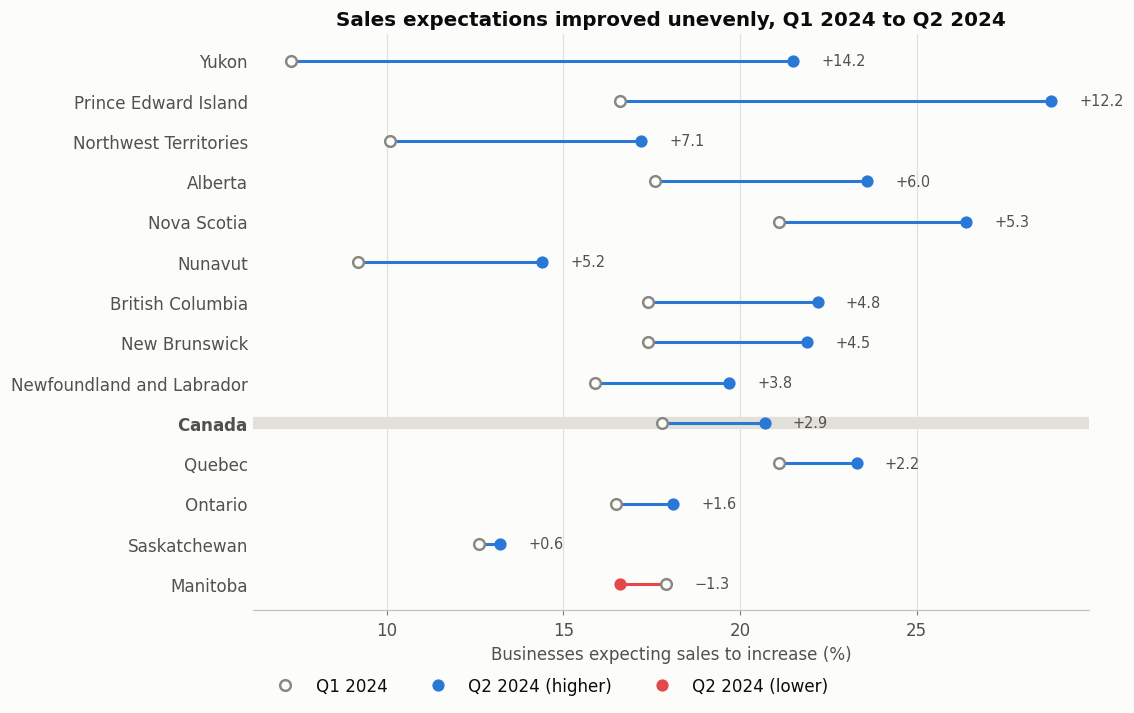

wrote outputs/analysis_3_metrics.csv


In [ ]:
csbc.regional_dumbbell_chart(
    csbc_data, "Q1 2024", "Q2 2024",
    csbc.OUTPUT_DIR / "analysis_3_regional_dispersion.png",
)
regional.to_csv(csbc.OUTPUT_DIR / "analysis_3_metrics.csv")
print("wrote outputs/analysis_3_metrics.csv")

## The volatility caveat

The eye is drawn to Yukon (+14.2 pp) and Prince Edward Island (+12.2 pp). Before repeating those
numbers to anyone, it is worth checking how much those jurisdictions normally move.

In [ ]:
small = ["Yukon", "Northwest Territories", "Nunavut", "Prince Edward Island"]
large = ["Ontario", "Quebec", "British Columbia", "Alberta"]

print(f"mean 4-quarter volatility, four smallest jurisdictions: "
      f"{regional.loc[small, 'volatility_sd'].mean():.1f} pp")
print(f"mean 4-quarter volatility, four largest provinces      : "
      f"{regional.loc[large, 'volatility_sd'].mean():.1f} pp")

regional.loc[small + large, ["Q1 2024", "Q2 2024", "change_pp", "volatility_sd"]]

mean 4-quarter volatility, four smallest jurisdictions: 5.2 pp
mean 4-quarter volatility, four largest provinces      : 2.6 pp


,Q1 2024,Q2 2024,change_pp,volatility_sd
GEO,,,,
Yukon,7.3,21.5,14.2,6.2
Northwest Territories,10.1,17.2,7.1,3.1
Nunavut,9.2,14.4,5.2,4.6
Prince Edward Island,16.6,28.8,12.2,6.9
Ontario,16.5,18.1,1.6,1.9
Quebec,21.1,23.3,2.2,1.8
British Columbia,17.4,22.2,4.8,3.1
Alberta,17.6,23.6,6.0,3.6


The small jurisdictions swing about **twice as much** quarter to quarter as the large provinces. A
+14 pp move in Yukon is not evidence of a Yukon boom it is close to ordinary noise for a
jurisdiction that volatile. The large provinces' smaller moves carry far more information per
percentage point.

This is why the metric table ships the volatility column: the caveat has to travel with the number.

## Interpretation

The national **+2.9 pp** improvement in sales expectations conceals a spread from **−1.3 pp to
+14.2 pp** across jurisdictions.

- **12 of 13 jurisdictions improved**; **Manitoba was the only decline (−1.3 pp)**, and Saskatchewan
  was effectively flat (+0.6 pp).
- **The two largest economies lagged the national figure.** Ontario improved just **+1.6 pp** and
  Quebec **+2.2 pp**, both below the national +2.9. The national number is pulled up by **Alberta
  (+6.0)**, **British Columbia (+4.8)** and Atlantic Canada.
- The biggest headline swings: Yukon, PEI come from the most volatile jurisdictions and should be
  discounted accordingly.

So the improvement is real but **regionally concentrated in the West and Atlantic Canada**, while
most Canadian businesses: the ones in Ontario and Quebec, saw a considerably weaker improvement
than the national headline suggests.

**What I would tell a stakeholder.** Be careful quoting the national figure as "how Canadian
businesses feel". A member in Ontario experienced roughly half the improvement the national number
implies, and one in Manitoba experienced none. If this informs regional programme decisions, the
provincial detail matters more than the national average, and any decision keyed to the territories
should treat single-quarter movements there as provisional.

---

**Next:** `06_observations_and_conclusions.ipynb`: putting the three analyses together.

